In [1]:
import pandas as pd

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
pd.__version__

'1.4.2'

In [33]:
df = pd.read_parquet('https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2024-01.parquet')

In [6]:
df.head()


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee
0,2,2024-01-01 00:57:55,2024-01-01 01:17:43,1.0,1.72,1.0,N,186,79,2,17.7,1.0,0.5,0.00,0.0,1.0,22.70,2.5,0.0
1,1,2024-01-01 00:03:00,2024-01-01 00:09:36,1.0,1.80,1.0,N,140,236,1,10.0,3.5,0.5,3.75,0.0,1.0,18.75,2.5,0.0
2,1,2024-01-01 00:17:06,2024-01-01 00:35:01,1.0,4.70,1.0,N,236,79,1,23.3,3.5,0.5,3.00,0.0,1.0,31.30,2.5,0.0
3,1,2024-01-01 00:36:38,2024-01-01 00:44:56,1.0,1.40,1.0,N,79,211,1,10.0,3.5,0.5,2.00,0.0,1.0,17.00,2.5,0.0
4,1,2024-01-01 00:46:51,2024-01-01 00:52:57,1.0,0.80,1.0,N,211,148,1,7.9,3.5,0.5,3.20,0.0,1.0,16.10,2.5,0.0


In [8]:
import sklearn

In [9]:
len(df.columns)

19

In [34]:
df['duration'] = pd.to_datetime(df.tpep_dropoff_datetime) - pd.to_datetime(df.tpep_pickup_datetime)

In [15]:
td = df.duration.iloc[0]

In [17]:
td.total_seconds()/60

19.8

In [37]:
df['duration'] = df.duration.apply(lambda td: td.total_seconds()/60)

In [20]:
# df = df[df.payment_type==2]

/home/codespace/anaconda3/lib/python3.9/site-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


<AxesSubplot:xlabel='duration', ylabel='Density'>

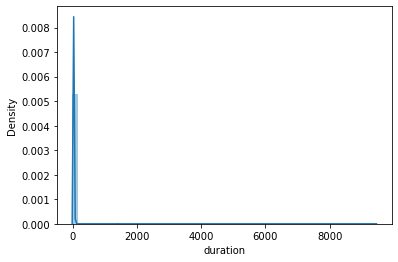

In [38]:
sns.distplot(df.duration)

In [39]:
df.duration.describe(percentiles=[0.95,0.98,0.99]
)

count    2.964624e+06
mean     1.561295e+01
std      3.485105e+01
min     -1.356667e+01
50%      1.163333e+01
95%      3.793333e+01
98%      5.100000e+01
99%      6.045000e+01
max      9.455400e+03
Name: duration, dtype: float64

/home/codespace/anaconda3/lib/python3.9/site-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


<AxesSubplot:xlabel='duration', ylabel='Density'>

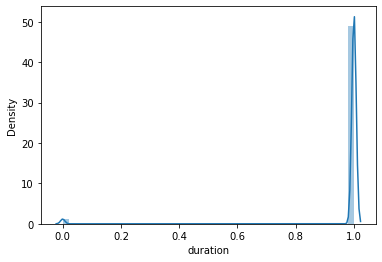

In [40]:
sns.distplot(((df.duration >= 1)  & (df.duration <=60)))


In [41]:
df.duration

0          19.800000
1           6.600000
2          17.916667
3           8.300000
4           6.100000
             ...    
2964619     8.616667
2964620    14.750000
2964621    19.000000
2964622    17.850000
2964623    15.083333
Name: duration, Length: 2964624, dtype: float64

In [43]:
categorical = ['PULocationID', 'DOLocationID']